<a href="https://colab.research.google.com/github/panindarkwah/Neural_NetworkLab---3/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


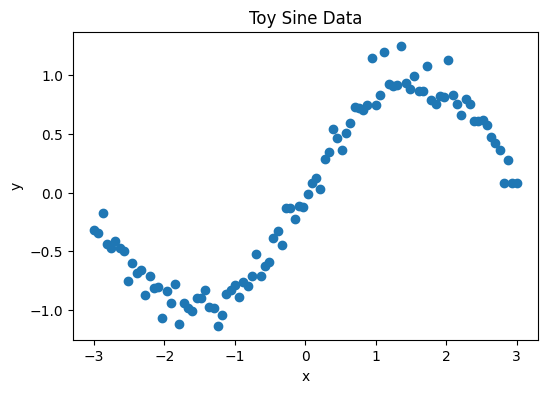

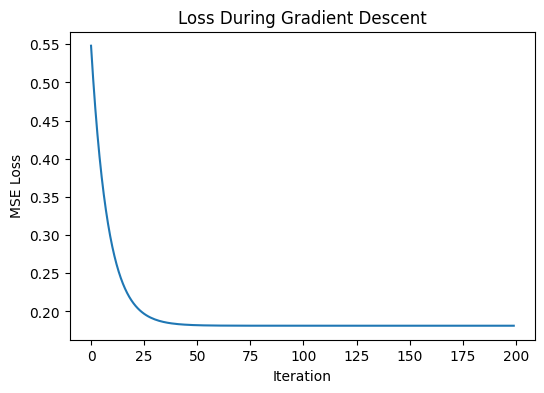

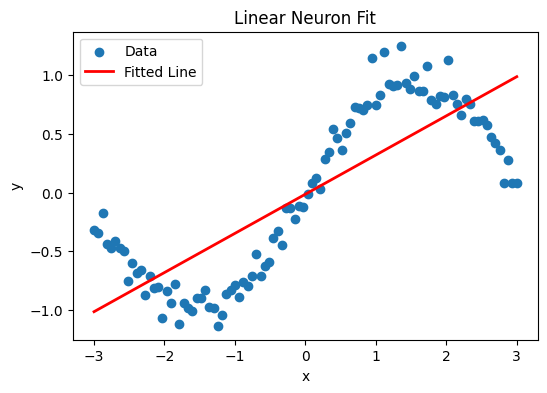

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# TODO: Generate the toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)
#   Plot it.
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy Sine Data")
plt.show()


# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01

lr = 0.01
losses = []

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
for i in range(200):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    w -= lr * dw
    b -= lr * db

# TODO: Plot (a) the loss curve over the 200 steps, and
# Plot the loss
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title("Loss During Gradient Descent")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.show()

# Plot the fitted line
y_hat = w * x + b

#(b) the data with the fitted line on top.
plt.figure(figsize=(6,4))
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, color="red", linewidth=2, label="Fitted Line")
plt.title("Linear Neuron Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

1.
### Derivation of $\frac{\partial \text{Loss}}{\partial w}$

The prediction is:

$$
\hat{y} = wx + b
$$

The Mean Squared Error loss is:

$$
L = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i-y_i)^2
$$

Differentiate with respect to $w$:

$$
\frac{\partial L}{\partial w}
=
\frac{1}{n}
\sum_{i=1}^{n}
2(\hat{y}_i-y_i)x_i
$$

Therefore,

$$
\frac{\partial L}{\partial w}
=
\text{mean}\left(2(\hat{y}-y)x\right)
$$

This matches the code:

```python
dw = np.mean(2 * (y_hat - y) * x)
```

PART 1.1

2. The fit stops improving even though the fit is bad because, the single neuron only computes a linear function, hower the target data is generated from y = sin(x) + noise, which is a non-linear function. The gradient descent can only adjust the values of w and b; it cannot change the model from a straight line to a curve. After multiple iterations, it just finds the line that best fits, so the loss stops decreasing. To model the target, we need a model capable of representing nonlinear relationships, such as a neural network with one or more hidden layers and nonlinear activation functions
The poor fit is caused by underfitting because the model is too simple to represent the nonlinear pattern in the data.